# Exploración y Limpieza del Dataset de Churn Eléctrico

**TFG — Diego Suárez | Tutor: Luciano**

---

Este notebook documenta el proceso de exploración y limpieza del fichero
`datos_anonimizados.csv` antes de aplicar RSF-PHATE.

Secciones:
1. Carga y visión general
2. Valores missing
3. Variable objetivo (TARGET) y variable de tiempo (ANTIGUEDAD_CLIENTE)
4. Variables numéricas: distribuciones y outliers
5. Variables categóricas: cardinalidad y frecuencias
6. Variables de multicontrato
7. Correlaciones con TARGET
8. Decisiones de limpieza — resumen de cambios


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_PATH = os.path.abspath(
    os.path.join('..', '..', 'ClusterScripts', 'datos_anonimizados.csv')
)
print('Imports OK')
print('Ruta datos:', DATA_PATH)


Imports OK
Ruta datos: C:\Users\diego\OneDrive\Documentos\TFG\ClusterScripts\datos_anonimizados.csv


## 1. Carga y visión general

In [2]:
df = pd.read_csv(DATA_PATH, encoding='iso-8859-1')

print('=== DIMENSIONES ===')
print(f'  Filas:    {df.shape[0]:>10,}')
print(f'  Columnas: {df.shape[1]:>10}')

print('\n=== TIPOS DE DATO ===')
type_counts = df.dtypes.value_counts()
for dtype, n in type_counts.items():
    print(f'  {str(dtype):<12} {n} columnas')

print('\n=== PRIMERAS 3 FILAS ===')
display(df.head(3))


=== DIMENSIONES ===
  Filas:       678,750
  Columnas:         54

=== TIPOS DE DATO ===
  int64        32 columnas
  float64      12 columnas
  object       10 columnas

=== PRIMERAS 3 FILAS ===


,ACCESOS_AC_ML_3MESES_MOD,ANTIG_CLI_RANGO,ANTIGUEDAD,ANTIGUEDAD_CLIENTE,CANAL_INPUT,CANJE_PUNTOS_FECHA_REF_3_BIN,CARTERA_MEDIA,CHURN_COD_POSTAL,DESC_TV_MOD,DIAS_FIN_PROMO,DIAS_FIN_PROMO_RANGO,DIAS_PARA_RENOVAR,DIAS_PARA_RENOVAR_MOD,DIAS_ULTIMA_FACTURA,EFACTURA,FACTURACION_ALTA,FECHA_ALTA_INSTALACION,FECHA_BAJA_INSTALACION,IMP_CONSUMO_ACTIVA_MOD,IMP_DEUDA_VENCIDA,IMP_PRECIO_MAX,IND_Alta_Adva,N_ATC_FECHA_REF_3_MOD,N_CONTACTO_FECHA_REF_1,N_CONTACTO_FECHA_REF_2,N_CONTACTO_FECHA_REF_3,N_CTOS_ACTIVOS_IC,N_CTOS_BAJA_UMES_IC_MOD,N_FACILITA_FECHA_REF_3_MOD,N_FACT_COBR_FECHA_REF_3_MOD,N_GESTION_FECHA_REF_3_MOD,N_OOSS_ASIST_MOD,N_OOSS_MANT_MOD,N_OOSS_SSAA_MOD,N_ORDENES_SERVICIO_MOD,N_PEDIDOINFO_FECHA_REF_3_BIN,N_PEDIDOINFO_FECHA_REF_3_MOD,N_RECLAM_FECHA_REF_3_MOD,N_VENTAS_CONT_FECHA_REF_3_MOD,NUM_CONTRATO,NUM_CTOS_01_MOD,NUM_CTOS_02_MOD,NUM_CTOS_05_MOD,NUM_CTOS_L1_MOD,NUM_CTOS_L2_MOD,PROVINCIA_AGR,PROVINCIA_PS,RENOVACION_CAPTACION_MOD,SUBCANAL_INPUT,NBAJAS_36M_MOD,N_ALTAS_L1_IC,GEN_MOD,COD_SEXO,TARGET
0,0,6,6488,6505,CANAL 1,0,9948.000,0.014,4,NaN,0,NaN,NaN,9.000,0,0.000,26OCT2005:00:00:00,31DEC9999:00:00:00,468.000,0.000,200,N,0,NaN,NaN,NaN,4,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2,1,PROVINCIA_AGR 1,PROVINCIA 1,TRIMESTRAL,SUBCANAL 1,0,2,V,N,1
1,1,6,6485,6505,CANAL 1,0,5665.500,0.013,0,NaN,0,NaN,NaN,34.000,1,0.000,29OCT2005:00:00:00,31DEC9999:00:00:00,908.000,0.000,200,N,0,NaN,NaN,NaN,6,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,2,2,2,PROVINCIA_AGR 1,PROVINCIA 1,TRIMESTRAL,SUBCANAL 1,0,2,V,V,0
2,0,6,6485,6505,CANAL 1,0,5360.500,0.014,7,1021.000,2,219.000,219.000,19.000,0,0.000,29OCT2005:00:00:00,31DEC9999:00:00:00,1915.000,0.000,332,N,0,NaN,NaN,NaN,3,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,1,1,1,PROVINCIA_AGR 1,PROVINCIA 1,RENOVACION,SUBCANAL 1,0,1,V,V,0


In [3]:
# Clasificacion manual de columnas por tipo de informacion
cols_fecha      = ['FECHA_ALTA_INSTALACION', 'FECHA_BAJA_INSTALACION']
cols_target     = ['TARGET']
cols_tiempo     = ['ANTIGUEDAD_CLIENTE', 'ANTIGUEDAD']
cols_id         = ['NUM_CONTRATO']
cols_cat        = ['CANAL_INPUT', 'SUBCANAL_INPUT', 'PROVINCIA_PS', 'PROVINCIA_AGR',
                   'RENOVACION_CAPTACION_MOD', 'GEN_MOD', 'IND_Alta_Adva',
                   'COD_SEXO', 'ANTIG_CLI_RANGO', 'DIAS_FIN_PROMO_RANGO']
cols_multicto   = ['N_CTOS_ACTIVOS_IC', 'N_CTOS_BAJA_UMES_IC_MOD',
                   'NUM_CTOS_01_MOD', 'NUM_CTOS_02_MOD', 'NUM_CTOS_05_MOD',
                   'NUM_CTOS_L1_MOD', 'NUM_CTOS_L2_MOD', 'N_ALTAS_L1_IC']
cols_financiero = ['CARTERA_MEDIA', 'IMP_CONSUMO_ACTIVA_MOD', 'IMP_DEUDA_VENCIDA',
                   'IMP_PRECIO_MAX', 'FACTURACION_ALTA']
cols_servicio   = ['N_CONTACTO_FECHA_REF_1', 'N_CONTACTO_FECHA_REF_2', 'N_CONTACTO_FECHA_REF_3',
                   'N_ATC_FECHA_REF_3_MOD', 'N_RECLAM_FECHA_REF_3_MOD', 'N_GESTION_FECHA_REF_3_MOD',
                   'N_FACILITA_FECHA_REF_3_MOD', 'N_FACT_COBR_FECHA_REF_3_MOD',
                   'N_PEDIDOINFO_FECHA_REF_3_MOD', 'N_PEDIDOINFO_FECHA_REF_3_BIN',
                   'N_VENTAS_CONT_FECHA_REF_3_MOD', 'N_OOSS_ASIST_MOD',
                   'N_OOSS_MANT_MOD', 'N_OOSS_SSAA_MOD', 'N_ORDENES_SERVICIO_MOD',
                   'CANJE_PUNTOS_FECHA_REF_3_BIN', 'ACCESOS_AC_ML_3MESES_MOD']
cols_contrato   = ['DIAS_FIN_PROMO', 'DIAS_PARA_RENOVAR', 'DIAS_PARA_RENOVAR_MOD',
                   'DIAS_ULTIMA_FACTURA', 'EFACTURA', 'DESC_TV_MOD',
                   'NBAJAS_36M_MOD', 'CHURN_COD_POSTAL']

all_classified = (cols_fecha + cols_target + cols_tiempo + cols_id + cols_cat +
                  cols_multicto + cols_financiero + cols_servicio + cols_contrato)
no_clasificadas = [c for c in df.columns if c not in all_classified]

print('Columnas por categoria:')
for nombre, cols in [
    ('Fechas',       cols_fecha),
    ('Target',       cols_target),
    ('Tiempo',       cols_tiempo),
    ('Identificador',cols_id),
    ('Categoricas',  cols_cat),
    ('Multicontrato',cols_multicto),
    ('Financieras',  cols_financiero),
    ('Servicio',     cols_servicio),
    ('Contrato',     cols_contrato),
]:
    print(f'  {nombre:<16} {len(cols):>2} cols: {cols}')
if no_clasificadas:
    print(f'  Sin clasificar: {no_clasificadas}')


Columnas por categoria:
  Fechas            2 cols: ['FECHA_ALTA_INSTALACION', 'FECHA_BAJA_INSTALACION']
  Target            1 cols: ['TARGET']
  Tiempo            2 cols: ['ANTIGUEDAD_CLIENTE', 'ANTIGUEDAD']
  Identificador     1 cols: ['NUM_CONTRATO']
  Categoricas      10 cols: ['CANAL_INPUT', 'SUBCANAL_INPUT', 'PROVINCIA_PS', 'PROVINCIA_AGR', 'RENOVACION_CAPTACION_MOD', 'GEN_MOD', 'IND_Alta_Adva', 'COD_SEXO', 'ANTIG_CLI_RANGO', 'DIAS_FIN_PROMO_RANGO']
  Multicontrato     8 cols: ['N_CTOS_ACTIVOS_IC', 'N_CTOS_BAJA_UMES_IC_MOD', 'NUM_CTOS_01_MOD', 'NUM_CTOS_02_MOD', 'NUM_CTOS_05_MOD', 'NUM_CTOS_L1_MOD', 'NUM_CTOS_L2_MOD', 'N_ALTAS_L1_IC']
  Financieras       5 cols: ['CARTERA_MEDIA', 'IMP_CONSUMO_ACTIVA_MOD', 'IMP_DEUDA_VENCIDA', 'IMP_PRECIO_MAX', 'FACTURACION_ALTA']
  Servicio         17 cols: ['N_CONTACTO_FECHA_REF_1', 'N_CONTACTO_FECHA_REF_2', 'N_CONTACTO_FECHA_REF_3', 'N_ATC_FECHA_REF_3_MOD', 'N_RECLAM_FECHA_REF_3_MOD', 'N_GESTION_FECHA_REF_3_MOD', 'N_FACILITA_FECHA_REF_3_MOD', '

## 2. Valores missing

In [4]:
# Conteo y porcentaje de NaN por columna
missing = pd.DataFrame({
    'n_missing':  df.isnull().sum(),
    'pct_missing': df.isnull().mean() * 100,
}).sort_values('pct_missing', ascending=False)

missing_cols = missing[missing.n_missing > 0]
print(f'Columnas con algun NaN: {len(missing_cols)} de {df.shape[1]}')
print()
display(missing_cols.style.format({'n_missing': '{:,}', 'pct_missing': '{:.1f}%'})
        .background_gradient(subset=['pct_missing'], cmap='Reds'))


Columnas con algun NaN: 11 de 54



,n_missing,pct_missing
DIAS_FIN_PROMO,"517,222",76.2%
N_CONTACTO_FECHA_REF_3,"469,777",69.2%
N_CONTACTO_FECHA_REF_1,"469,777",69.2%
N_CONTACTO_FECHA_REF_2,"469,777",69.2%
DIAS_PARA_RENOVAR_MOD,"394,876",58.2%
DIAS_PARA_RENOVAR,"393,291",57.9%
CHURN_COD_POSTAL,"29,090",4.3%
FACTURACION_ALTA,"14,046",2.1%
DIAS_ULTIMA_FACTURA,"4,503",0.7%
IMP_DEUDA_VENCIDA,"4,004",0.6%


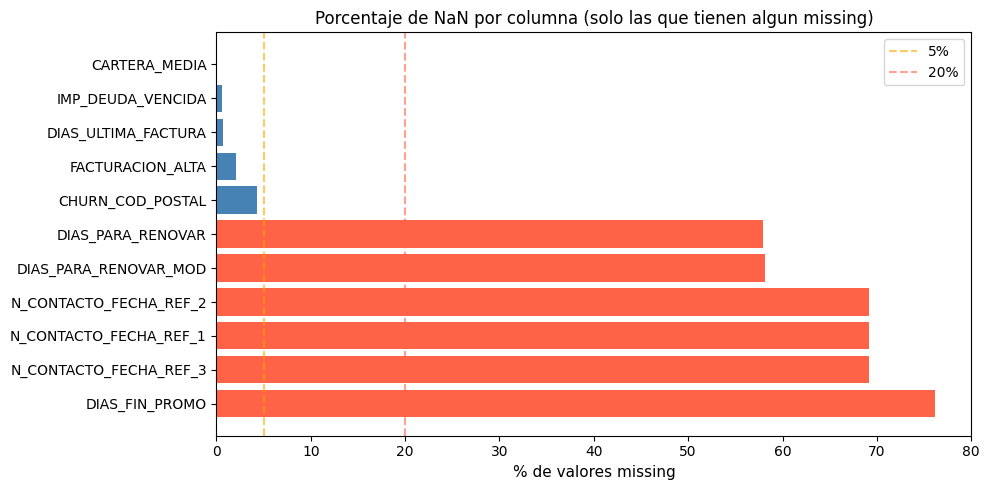

In [5]:
# Visualizacion del porcentaje de NaN por columna
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    missing_cols.index,
    missing_cols['pct_missing'],
    color=['tomato' if p > 20 else 'orange' if p > 5 else 'steelblue'
           for p in missing_cols['pct_missing']]
)
ax.axvline(5,  color='orange', linestyle='--', alpha=0.6, label='5%')
ax.axvline(20, color='tomato',  linestyle='--', alpha=0.6, label='20%')
ax.set_xlabel('% de valores missing', fontsize=11)
ax.set_title('Porcentaje de NaN por columna (solo las que tienen algun missing)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


## 3. Variable objetivo y variable de tiempo

=== TARGET (churn) ===
  Sin churn (0):   630,390  (92.88%)
  Con churn (1):    48,360  (7.12%)
  Total:           678,750
  Desbalance 0/1: 13.0:1


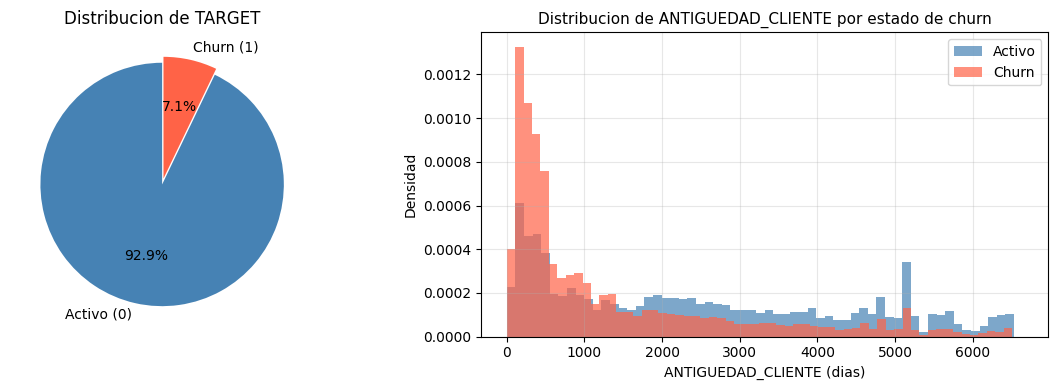

In [6]:
# Distribucion de TARGET (churn)
vc = df['TARGET'].value_counts()
print('=== TARGET (churn) ===')
print(f'  Sin churn (0): {vc[0]:>9,}  ({vc[0]/len(df):.2%})')
print(f'  Con churn (1): {vc[1]:>9,}  ({vc[1]/len(df):.2%})')
print(f'  Total:         {len(df):>9,}')
print(f'  Desbalance 0/1: {vc[0]/vc[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie([vc[0], vc[1]], labels=['Activo (0)', 'Churn (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, explode=[0, 0.05])
axes[0].set_title('Distribucion de TARGET', fontsize=12)

# Distribucion de ANTIGUEDAD_CLIENTE por TARGET
for val, label, color in [(0, 'Activo', 'steelblue'), (1, 'Churn', 'tomato')]:
    axes[1].hist(df.loc[df.TARGET==val, 'ANTIGUEDAD_CLIENTE'],
                 bins=60, alpha=0.7, color=color, label=label, density=True)
axes[1].set_xlabel('ANTIGUEDAD_CLIENTE (dias)', fontsize=10)
axes[1].set_ylabel('Densidad', fontsize=10)
axes[1].set_title('Distribucion de ANTIGUEDAD_CLIENTE por estado de churn', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
# Estadisticas de ANTIGUEDAD_CLIENTE por grupo
print('=== ANTIGUEDAD_CLIENTE (dias) ===')
for val, label in [(0, 'Activo (TARGET=0)'), (1, 'Churn (TARGET=1)'), (None, 'Total')]:
    if val is None:
        s = df['ANTIGUEDAD_CLIENTE']
    else:
        s = df.loc[df.TARGET == val, 'ANTIGUEDAD_CLIENTE']
    print(f'  {label}:')
    print(f'    Min: {s.min():.0f} d ({s.min()/365:.1f} a)   '
          f'Mediana: {s.median():.0f} d ({s.median()/365:.1f} a)   '
          f'Max: {s.max():.0f} d ({s.max()/365:.1f} a)   '
          f'Media: {s.mean():.0f} d')
    print()

print('Interpretacion:')
print('  - ANTIGUEDAD_CLIENTE esta en DIAS (no meses como podria parecer por el nombre).')
print('  - Los churns tienen mediana mucho menor que los activos: se van antes.')
print('  - El maximo de ~6500 dias = ~17.8 anos: cartera muy madura.')


=== ANTIGUEDAD_CLIENTE (dias) ===
  Activo (TARGET=0):
    Min: 1 d (0.0 a)   Mediana: 2115 d (5.8 a)   Max: 6641 d (18.2 a)   Media: 2444 d

  Churn (TARGET=1):
    Min: 1 d (0.0 a)   Mediana: 583 d (1.6 a)   Max: 6505 d (17.8 a)   Media: 1320 d

  Total:
    Min: 1 d (0.0 a)   Mediana: 2000 d (5.5 a)   Max: 6641 d (18.2 a)   Media: 2364 d

Interpretacion:
  - ANTIGUEDAD_CLIENTE esta en DIAS (no meses como podria parecer por el nombre).
  - Los churns tienen mediana mucho menor que los activos: se van antes.
  - El maximo de ~6500 dias = ~17.8 anos: cartera muy madura.


## 4. Variables numéricas — distribuciones y outliers

In [8]:
# Variables numericas (excluimos fechas, target, id)
nums = df.select_dtypes(include='number').columns.tolist()
nums = [c for c in nums if c not in ['TARGET']]

print(f'Variables numericas: {len(nums)}')
stats = df[nums].describe().T
stats['pct_missing'] = (df[nums].isnull().mean() * 100).round(1)
stats['pct_cero']    = (df[nums].eq(0).mean()   * 100).round(1)
display(stats[['count','mean','std','min','25%','50%','75%','max','pct_missing','pct_cero']].round(2))


Variables numericas: 43


,count,mean,std,min,25%,50%,75%,max,pct_missing,pct_cero
ACCESOS_AC_ML_3MESES_MOD,678750.000,0.430,0.490,0.000,0.000,0.000,1.000,1.000,0.000,57.300
ANTIG_CLI_RANGO,678750.000,4.940,1.380,1.000,4.000,6.000,6.000,6.000,0.000,0.000
ANTIGUEDAD,678750.000,2522.940,1863.380,90.000,674.250,2307.000,4165.000,6509.000,0.000,0.000
ANTIGUEDAD_CLIENTE,678750.000,2364.090,1901.580,1.000,528.000,2000.000,3890.000,6641.000,0.000,0.000
CANJE_PUNTOS_FECHA_REF_3_BIN,678750.000,0.000,0.050,0.000,0.000,0.000,0.000,1.000,0.000,99.800
CARTERA_MEDIA,678748.000,1968.120,2895.540,1.000,204.500,621.500,2397.500,13692.500,0.000,0.000
CHURN_COD_POSTAL,649660.000,0.030,0.030,0.000,0.010,0.020,0.050,1.330,4.300,0.400
DESC_TV_MOD,678750.000,4.040,2.580,0.000,2.000,4.000,7.000,30.000,0.000,13.700
DIAS_FIN_PROMO,161528.000,804.620,19180.020,0.000,191.000,957.000,1055.000,2913324.000,76.200,0.100
DIAS_FIN_PROMO_RANGO,678750.000,0.400,0.780,0.000,0.000,0.000,0.000,3.000,0.000,76.200


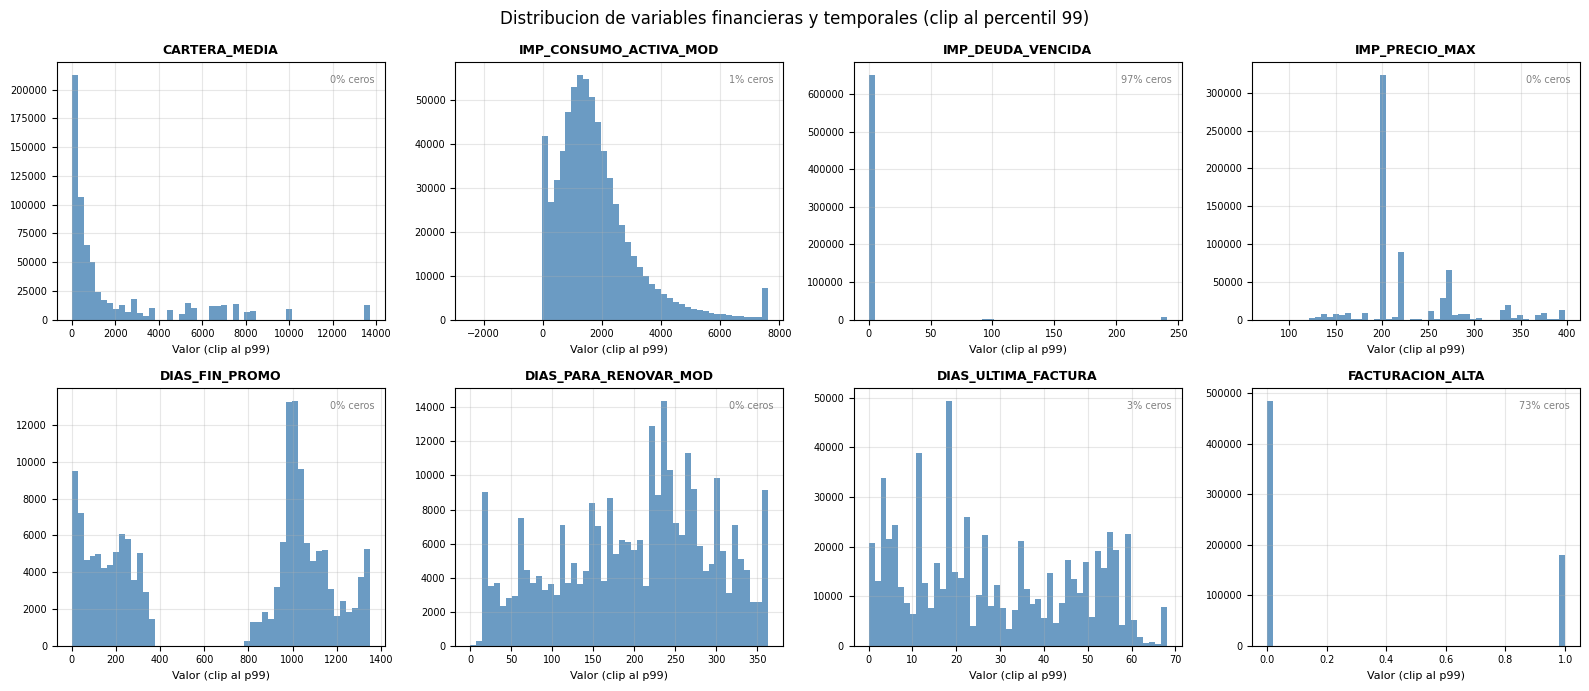

In [9]:
# Histogramas de las variables financieras y de tiempo clave
cols_plot = ['CARTERA_MEDIA', 'IMP_CONSUMO_ACTIVA_MOD', 'IMP_DEUDA_VENCIDA',
             'IMP_PRECIO_MAX', 'DIAS_FIN_PROMO', 'DIAS_PARA_RENOVAR_MOD',
             'DIAS_ULTIMA_FACTURA', 'FACTURACION_ALTA']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, cols_plot):
    data = df[col].dropna()
    # Truncar al percentil 99 para evitar que los outliers colapsen el histograma
    p99 = data.quantile(0.99)
    ax.hist(data.clip(upper=p99), bins=50, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor (clip al p99)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    # Indicar el % de ceros
    pct_zero = (data == 0).mean() * 100
    ax.text(0.97, 0.95, f'{pct_zero:.0f}% ceros', transform=ax.transAxes,
            ha='right', va='top', fontsize=7, color='gray')

plt.suptitle('Distribucion de variables financieras y temporales (clip al percentil 99)', fontsize=12)
plt.tight_layout()
plt.show()


In [10]:
# Analisis de outliers: columnas con valores extremos (IQR method)
print('=== COLUMNAS CON OUTLIERS SIGNIFICATIVOS (>5% fuera de IQR x3) ===')
result = []
for col in nums:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    outliers = ((s < q1 - 3*iqr) | (s > q3 + 3*iqr)).mean() * 100
    if outliers > 1:
        result.append({'columna': col, 'pct_outliers': outliers,
                       'max': s.max(), 'p99': s.quantile(0.99)})

if result:
    display(pd.DataFrame(result).sort_values('pct_outliers', ascending=False).round(2))
else:
    print('  Ninguna columna tiene mas del 1% de outliers extremos.')


=== COLUMNAS CON OUTLIERS SIGNIFICATIVOS (>5% fuera de IQR x3) ===


,columna,pct_outliers,max,p99
0,CARTERA_MEDIA,3.210,13692.500,13692.500
8,N_ALTAS_L1_IC,2.400,76.000,7.000
6,N_GESTION_FECHA_REF_3_MOD,1.540,40.000,5.000
3,N_CONTACTO_FECHA_REF_1,1.510,24.000,5.000
5,N_CTOS_ACTIVOS_IC,1.500,44.000,7.000
2,IMP_CONSUMO_ACTIVA_MOD,1.490,219519.110,7626.790
4,N_CONTACTO_FECHA_REF_3,1.490,52.000,11.000
7,NBAJAS_36M_MOD,1.230,33.000,5.000
1,CHURN_COD_POSTAL,1.070,1.330,0.140


## 5. Variables categóricas — cardinalidad y frecuencias

In [11]:
cats_texto = df.select_dtypes(include='object').columns.tolist()
print(f'Variables de tipo texto/objeto: {cats_texto}')
print()

for col in cats_texto:
    n_unique = df[col].nunique()
    top5 = df[col].value_counts().head(5)
    churn_by_cat = df.groupby(col)['TARGET'].mean().sort_values(ascending=False).head(5)
    print(f'--- {col} ({n_unique} valores unicos) ---')
    print('  Top 5 por frecuencia:')
    for val, cnt in top5.items():
        pct = cnt / len(df) * 100
        churn = df.loc[df[col]==val, 'TARGET'].mean() * 100
        print(f'    {str(val):<25} {cnt:>8,} ({pct:.1f}%)  churn={churn:.1f}%')
    print()


Variables de tipo texto/objeto: ['CANAL_INPUT', 'FECHA_ALTA_INSTALACION', 'FECHA_BAJA_INSTALACION', 'IND_Alta_Adva', 'PROVINCIA_AGR', 'PROVINCIA_PS', 'RENOVACION_CAPTACION_MOD', 'SUBCANAL_INPUT', 'GEN_MOD', 'COD_SEXO']

--- CANAL_INPUT (6 valores unicos) ---
  Top 5 por frecuencia:
    CANAL 1                    370,940 (54.7%)  churn=4.3%
    CANAL 5                    101,397 (14.9%)  churn=6.7%
    CANAL 6                     98,049 (14.4%)  churn=13.7%
    CANAL 2                     51,860 (7.6%)  churn=13.5%
    CANAL 4                     41,017 (6.0%)  churn=11.7%

--- FECHA_ALTA_INSTALACION (6168 valores unicos) ---
  Top 5 por frecuencia:
    12JUN2009:00:00:00           1,400 (0.2%)  churn=3.0%
    15APR2023:00:00:00           1,165 (0.2%)  churn=15.5%
    28APR2023:00:00:00           1,031 (0.2%)  churn=13.8%
    21APR2023:00:00:00           1,016 (0.1%)  churn=13.8%
    27APR2023:00:00:00           1,013 (0.1%)  churn=12.0%

--- FECHA_BAJA_INSTALACION (3 valores unicos) --

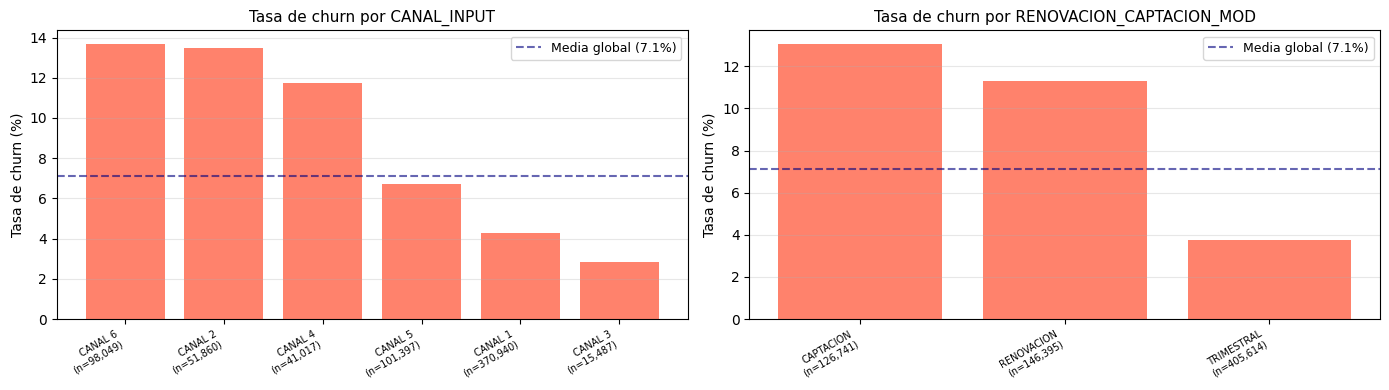

In [12]:
# Tasa de churn por canal de captacion (una de las mas discriminativas)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['CANAL_INPUT', 'RENOVACION_CAPTACION_MOD']):
    churn_by = df.groupby(col)['TARGET'].agg(['mean', 'count']).reset_index()
    churn_by = churn_by.sort_values('mean', ascending=False)
    churn_by['mean_pct'] = churn_by['mean'] * 100
    ax.bar(range(len(churn_by)), churn_by['mean_pct'], color='tomato', alpha=0.8)
    ax.set_xticks(range(len(churn_by)))
    ax.set_xticklabels(
        [f"{v}\n(n={n:,})" for v, n in zip(churn_by[col], churn_by['count'])],
        fontsize=7, rotation=30, ha='right'
    )
    ax.set_ylabel('Tasa de churn (%)', fontsize=10)
    ax.set_title(f'Tasa de churn por {col}', fontsize=11)
    ax.axhline(df['TARGET'].mean()*100, color='navy', linestyle='--',
               alpha=0.6, label=f'Media global ({df["TARGET"].mean()*100:.1f}%)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Variables de multicontrato

In [13]:
print('=== CONTRATOS POR CLIENTE (N_CTOS_ACTIVOS_IC) ===')
vc_ctos = df['N_CTOS_ACTIVOS_IC'].value_counts().sort_index()
for n_ctos, cnt in vc_ctos.head(10).items():
    churn = df.loc[df.N_CTOS_ACTIVOS_IC==n_ctos, 'TARGET'].mean() * 100
    print(f'  {n_ctos} contratos: {cnt:>8,} clientes ({cnt/len(df):.1%})  churn={churn:.1f}%')

print(f'\n  Media de contratos por cliente: {df["N_CTOS_ACTIVOS_IC"].mean():.2f}')
print(f'  Clientes con >1 contrato: {(df["N_CTOS_ACTIVOS_IC"]>1).mean():.1%}')
print()

print('=== TIPOS DE CONTRATO ADICIONALES ===')
for col in ['NUM_CTOS_01_MOD', 'NUM_CTOS_02_MOD', 'NUM_CTOS_05_MOD',
            'NUM_CTOS_L1_MOD', 'NUM_CTOS_L2_MOD']:
    tiene = (df[col] >= 1)
    churn_con    = df.loc[tiene,  'TARGET'].mean() * 100
    churn_sin    = df.loc[~tiene, 'TARGET'].mean() * 100
    print(f'  {col:<22}  {tiene.mean():.1%} tienen >=1'
          f'  |  churn CON: {churn_con:.1f}%  churn SIN: {churn_sin:.1f}%')


=== CONTRATOS POR CLIENTE (N_CTOS_ACTIVOS_IC) ===
  1 contratos:  145,067 clientes (21.4%)  churn=8.2%
  2 contratos:  253,615 clientes (37.4%)  churn=7.9%
  3 contratos:  197,482 clientes (29.1%)  churn=6.0%
  4 contratos:   40,207 clientes (5.9%)  churn=5.8%
  5 contratos:   20,016 clientes (2.9%)  churn=5.3%
  6 contratos:   12,168 clientes (1.8%)  churn=5.5%
  7 contratos:    4,049 clientes (0.6%)  churn=5.1%
  8 contratos:    2,328 clientes (0.3%)  churn=6.2%
  9 contratos:    1,368 clientes (0.2%)  churn=2.7%
  10 contratos:      677 clientes (0.1%)  churn=6.6%

  Media de contratos por cliente: 2.46
  Clientes con >1 contrato: 78.6%

=== TIPOS DE CONTRATO ADICIONALES ===
  NUM_CTOS_01_MOD         3.4% tienen >=1  |  churn CON: 3.4%  churn SIN: 7.3%
  NUM_CTOS_02_MOD         13.1% tienen >=1  |  churn CON: 5.7%  churn SIN: 7.3%
  NUM_CTOS_05_MOD         52.3% tienen >=1  |  churn CON: 7.4%  churn SIN: 6.8%
  NUM_CTOS_L1_MOD         100.0% tienen >=1  |  churn CON: 7.1%  churn SIN

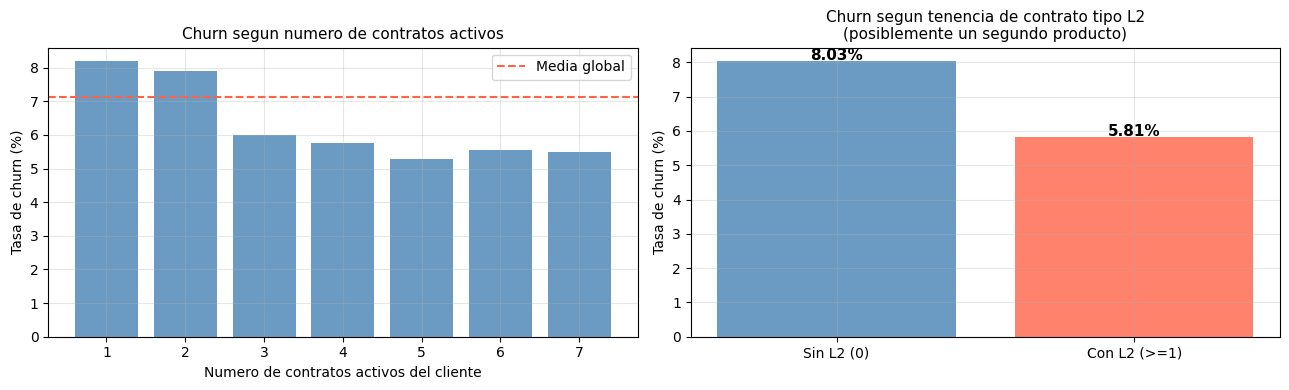

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Churn por numero de contratos
cto_churn = df.groupby(df['N_CTOS_ACTIVOS_IC'].clip(1,7))['TARGET'].mean() * 100
axes[0].bar(cto_churn.index, cto_churn.values, color='steelblue', alpha=0.8)
axes[0].axhline(df['TARGET'].mean()*100, color='tomato', linestyle='--',
                label='Media global')
axes[0].set_xlabel('Numero de contratos activos del cliente', fontsize=10)
axes[0].set_ylabel('Tasa de churn (%)', fontsize=10)
axes[0].set_title('Churn segun numero de contratos activos', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Churn con/sin tipo L2 (posiblemente gas)
tiene_l2   = df['NUM_CTOS_L2_MOD'] >= 1
churn_vals = [df.loc[~tiene_l2, 'TARGET'].mean()*100,
              df.loc[ tiene_l2, 'TARGET'].mean()*100]
axes[1].bar(['Sin L2 (0)', 'Con L2 (>=1)'], churn_vals,
            color=['steelblue', 'tomato'], alpha=0.8)
axes[1].set_ylabel('Tasa de churn (%)', fontsize=10)
axes[1].set_title('Churn segun tenencia de contrato tipo L2\n(posiblemente un segundo producto)', fontsize=11)
axes[1].grid(alpha=0.3)
for i, v in enumerate(churn_vals):
    axes[1].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Correlaciones con TARGET

In [15]:
# Correlacion de Pearson con TARGET para variables numericas
corr_target = df[nums + ['TARGET']].corr()['TARGET'].drop('TARGET')
corr_target = corr_target.sort_values(key=abs, ascending=False)

print('=== CORRELACION CON TARGET (top 20 en valor absoluto) ===')
display(corr_target.head(20).to_frame().style
        .format('{:.4f}')
        .background_gradient(cmap='RdBu_r', vmin=-0.15, vmax=0.15))


=== CORRELACION CON TARGET (top 20 en valor absoluto) ===


,TARGET
ANTIG_CLI_RANGO,-0.1625
ANTIGUEDAD,-0.1602
NUM_CONTRATO,0.1597
ANTIGUEDAD_CLIENTE,-0.1520
IMP_PRECIO_MAX,0.1119
CHURN_COD_POSTAL,0.1099
DIAS_FIN_PROMO_RANGO,0.0897
ACCESOS_AC_ML_3MESES_MOD,0.0810
EFACTURA,0.0789
CARTERA_MEDIA,-0.0769


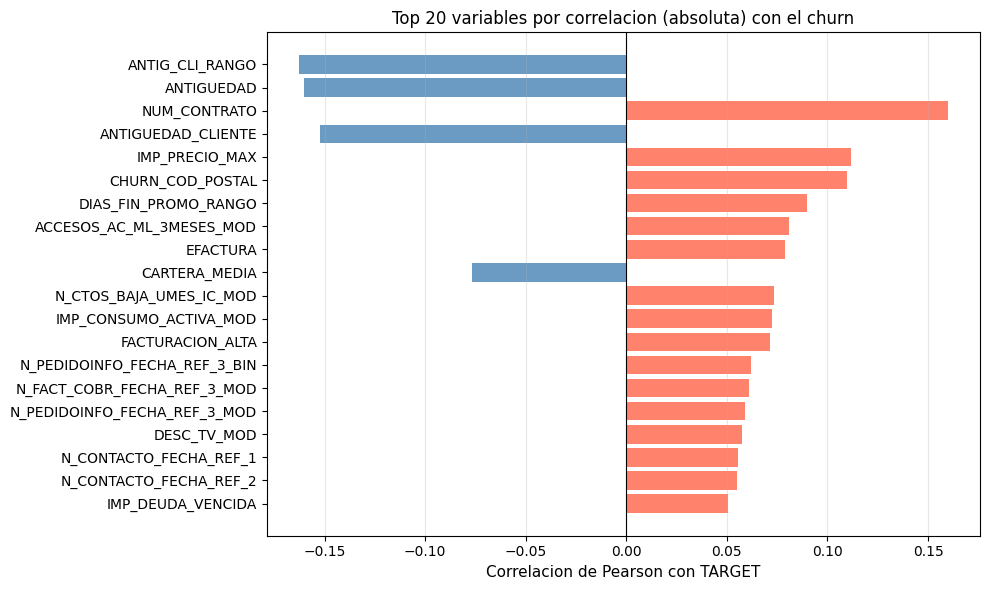

In [16]:
top20 = corr_target.head(20)
colors = ['tomato' if v > 0 else 'steelblue' for v in top20.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion de Pearson con TARGET', fontsize=11)
ax.set_title('Top 20 variables por correlacion (absoluta) con el churn', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


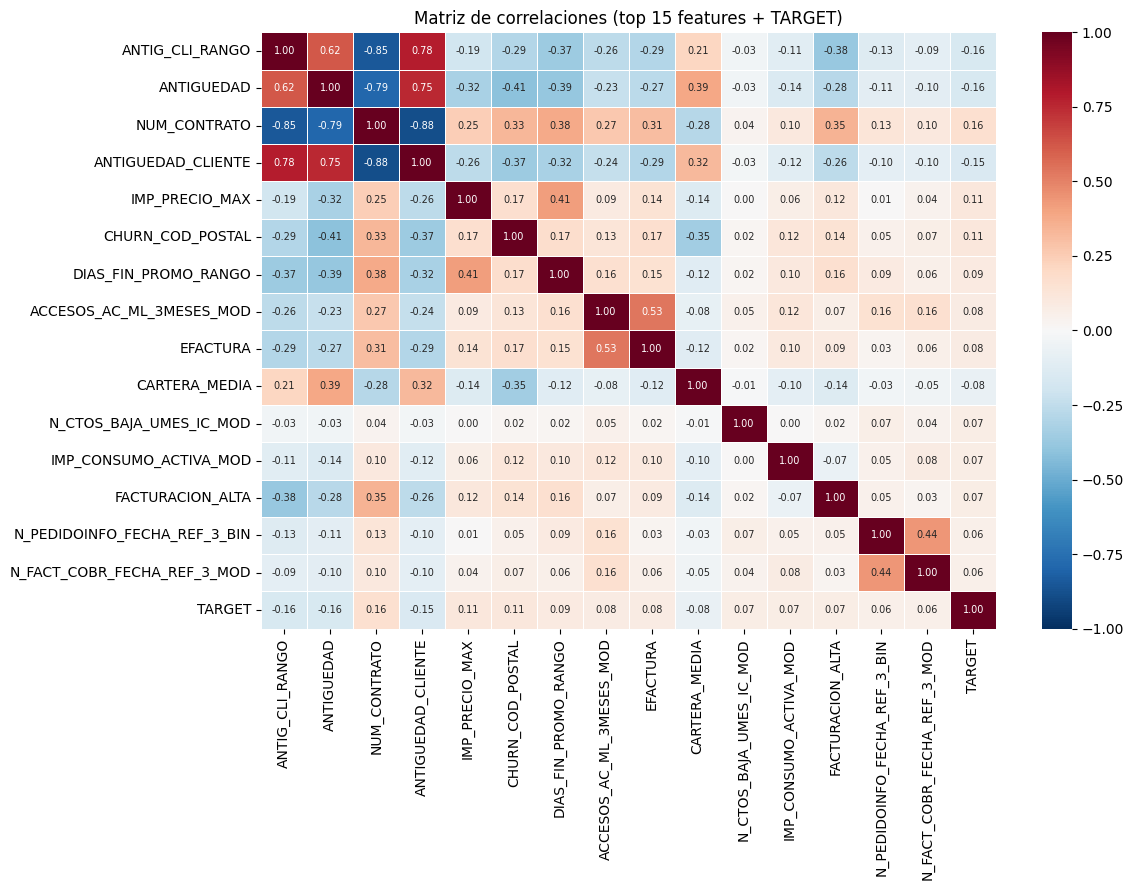

In [17]:
# Heatmap de correlaciones entre las top features
top_cols = corr_target.head(15).index.tolist() + ['TARGET']
corr_matrix = df[top_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 7},
)
ax.set_title('Matriz de correlaciones (top 15 features + TARGET)', fontsize=12)
plt.tight_layout()
plt.show()


## 8. Decisiones de limpieza — resumen de cambios

Esta sección documenta **qué se hace** en `churn_preprocessing.py` y **por qué**.


In [18]:
# Simulamos el preprocesado y mostramos los cambios paso a paso
from sklearn.preprocessing import LabelEncoder

df_work = df.copy()
n0 = len(df_work)
print(f'Punto de partida: {n0:,} filas x {df_work.shape[1]} columnas')
print()

# ── PASO 1: Separar variables de supervivencia ────────────────────────────────
print('PASO 1 — Separar variables de supervivencia')
print(f'  time  = ANTIGUEDAD_CLIENTE  (rango: {df_work.ANTIGUEDAD_CLIENTE.min():.0f}-{df_work.ANTIGUEDAD_CLIENTE.max():.0f} dias)')
print(f'  event = TARGET              (churn rate: {df_work.TARGET.mean():.2%})')
print()

# ── PASO 2: Columnas descartadas ─────────────────────────────────────────────
IGNORAR = [
    'NUM_CONTRATO',          # identificador, no predictivo
    'PROVINCIA_AGR',         # redundante con PROVINCIA_PS
    'FECHA_ALTA_INSTALACION',# informacion ya en ANTIGUEDAD_CLIENTE
    'FECHA_BAJA_INSTALACION',# informacion ya en TARGET + ANTIGUEDAD_CLIENTE
    'COD_SEXO',              # >40% de NaN, bajo valor predictivo
    'ANTIGUEDAD',            # redundante con ANTIGUEDAD_CLIENTE
    'CHURN_COD_POSTAL',      # proxied por PROVINCIA_PS
    'ANTIG_CLI_RANGO',       # version categorica de ANTIGUEDAD_CLIENTE
    'DIAS_FIN_PROMO_RANGO',  # version categorica de DIAS_FIN_PROMO
    'N_PEDIDOINFO_FECHA_REF_3_BIN', # version binaria de la variable MOD
    'N_CONTACTO_FECHA_REF_1',  # referencia temporal antigua
    'N_CONTACTO_FECHA_REF_2',  # referencia temporal antigua
    'DIAS_PARA_RENOVAR',       # 58% de NaN; redundante con MOD version
    'DURACION_PROMO',          # solo en ABT_ELECTRICIDAD, no en anonimizado
    'DURACION_PROMO_RANGO',    # idem
    'NOMBRE_IC',               # solo en ABT_ELECTRICIDAD
]
IGNORAR_presentes = [c for c in IGNORAR if c in df_work.columns]
print('PASO 2 — Columnas descartadas:')
for col in IGNORAR_presentes:
    pct_nan = df_work[col].isnull().mean() * 100
    print(f'  - {col:<35} ({pct_nan:.0f}% NaN)')
df_work.drop(columns=IGNORAR_presentes + ['TARGET', 'ANTIGUEDAD_CLIENTE'], errors='ignore', inplace=True)
print(f'  Columnas restantes: {df_work.shape[1]}')
print()

# ── PASO 3: Codificacion de categoricas ──────────────────────────────────────
CATEGORICAS = ['CANAL_INPUT','SUBCANAL_INPUT','PROVINCIA_PS',
               'RENOVACION_CAPTACION_MOD','GEN_MOD','IND_Alta_Adva']
cats_presentes = [c for c in CATEGORICAS if c in df_work.columns]
print('PASO 3 — Codificacion de categoricas (LabelEncoder):')
le = LabelEncoder()
for col in cats_presentes:
    n_vals = df_work[col].nunique()
    df_work[col] = le.fit_transform(df_work[col].astype(str))
    print(f'  {col:<30} {n_vals} valores unicos -> enteros 0..{n_vals-1}')
print()

# ── PASO 4: Relleno de NaN conocidos ─────────────────────────────────────────
FILL_ZERO = {'DIAS_PARA_RENOVAR_MOD': 0, 'DIAS_FIN_PROMO': 0, 'N_CONTACTO_FECHA_REF_3': 0}
print('PASO 4 — Relleno de NaN con 0 (significado semantico: "no aplica"):')
for col, val in FILL_ZERO.items():
    if col in df_work.columns:
        n_filled = df_work[col].isnull().sum()
        df_work[col] = df_work[col].fillna(val)
        print(f'  {col:<35} {n_filled:,} NaN rellenados con {val}')
print()

# ── PASO 5: Eliminacion de filas con NaN restantes ───────────────────────────
n_before = len(df_work)
df_work.dropna(inplace=True)
n_after = len(df_work)
print('PASO 5 — Eliminacion de filas con NaN restantes:')
remaining_nan = df.drop(columns=IGNORAR_presentes+['TARGET','ANTIGUEDAD_CLIENTE'], errors='ignore')
remaining_nan = remaining_nan.drop(columns=FILL_ZERO.keys(), errors='ignore')
nan_cols_left = remaining_nan.isnull().sum()
nan_cols_left = nan_cols_left[nan_cols_left > 0]
if len(nan_cols_left) > 0:
    print('  Columnas con NaN que causan eliminacion de filas:')
    for col, n in nan_cols_left.items():
        print(f'    {col:<35} {n:,} NaN ({n/len(df)*100:.1f}%)')
print(f'  Filas antes: {n_before:,}  |  Filas despues: {n_after:,}  |  Eliminadas: {n_before-n_after:,} ({(n_before-n_after)/n_before:.1%})')
print()

print('=== RESUMEN FINAL ===')
print(f'  Dataset original:      {len(df):>9,} filas x {df.shape[1]} columnas')
print(f'  Muestra de 1200 filas: {1200:>9,} filas x {df.shape[1]} columnas (antes del preprocesado)')
print(f'  Tras preprocesado:      ~{int(1200 * n_after/len(df)):>8,} filas x {df_work.shape[1]} features  (estimado)')


Punto de partida: 678,750 filas x 54 columnas

PASO 1 — Separar variables de supervivencia
  time  = ANTIGUEDAD_CLIENTE  (rango: 1-6641 dias)
  event = TARGET              (churn rate: 7.12%)

PASO 2 — Columnas descartadas:
  - NUM_CONTRATO                        (0% NaN)
  - PROVINCIA_AGR                       (0% NaN)
  - FECHA_ALTA_INSTALACION              (0% NaN)
  - FECHA_BAJA_INSTALACION              (0% NaN)
  - COD_SEXO                            (0% NaN)
  - ANTIGUEDAD                          (0% NaN)
  - CHURN_COD_POSTAL                    (4% NaN)
  - ANTIG_CLI_RANGO                     (0% NaN)
  - DIAS_FIN_PROMO_RANGO                (0% NaN)
  - N_PEDIDOINFO_FECHA_REF_3_BIN        (0% NaN)
  - N_CONTACTO_FECHA_REF_1              (69% NaN)
  - N_CONTACTO_FECHA_REF_2              (69% NaN)
  - DIAS_PARA_RENOVAR                   (58% NaN)
  Columnas restantes: 39

PASO 3 — Codificacion de categoricas (LabelEncoder):
  CANAL_INPUT                    6 valores unicos -> ente

In [19]:
# Tabla resumen de las decisiones de limpieza
decisiones = [
    ('NUM_CONTRATO',                'Descartada', 'Identificador unico, no predictivo'),
    ('PROVINCIA_AGR',               'Descartada', 'Redundante con PROVINCIA_PS (version agregada)'),
    ('FECHA_ALTA/BAJA_INSTALACION', 'Descartada', 'Info ya capturada en ANTIGUEDAD_CLIENTE y TARGET'),
    ('COD_SEXO',                    'Descartada', 'Mas del 40% de NaN, bajo valor predictivo'),
    ('ANTIGUEDAD',                  'Descartada', 'Redundante con ANTIGUEDAD_CLIENTE'),
    ('CHURN_COD_POSTAL',            'Descartada', 'Proxied por PROVINCIA_PS'),
    ('ANTIG_CLI_RANGO',             'Descartada', 'Version categorica de ANTIGUEDAD_CLIENTE (redundante)'),
    ('DIAS_FIN_PROMO_RANGO',        'Descartada', 'Version categorica de DIAS_FIN_PROMO (redundante)'),
    ('N_PEDIDOINFO_FECHA_REF_3_BIN','Descartada', 'Version binaria de la variable MOD ya incluida'),
    ('N_CONTACTO_FECHA_REF_1/2',    'Descartada', 'Referencias temporales antiguas, baja informacion'),
    ('DIAS_PARA_RENOVAR',           'Descartada', '58% NaN; MOD version incluida con NaN->0'),
    ('ANTIGUEDAD_CLIENTE',          'Uso survival', 'Variable de tiempo T (dias hasta churn o censura)'),
    ('TARGET',                      'Uso survival', 'Indicador de evento (1=churn, 0=censurado)'),
    ('DIAS_FIN_PROMO',              'NaN -> 0', 'NaN significa "sin promocion activa"'),
    ('DIAS_PARA_RENOVAR_MOD',       'NaN -> 0', 'NaN significa "sin fecha de renovacion pendiente"'),
    ('N_CONTACTO_FECHA_REF_3',      'NaN -> 0', 'NaN significa "sin contactos registrados"'),
    ('CANAL_INPUT / SUBCANAL_INPUT','LabelEncoded', 'Texto -> entero para el modelo'),
    ('PROVINCIA_PS',                'LabelEncoded', 'Texto -> entero (48 provincias anonimizadas)'),
    ('RENOVACION_CAPTACION_MOD',    'LabelEncoded', 'Texto -> entero'),
    ('GEN_MOD / IND_Alta_Adva',     'LabelEncoded', 'Texto -> entero'),
    ('FACTURACION_ALTA / DIAS_ULTIMA_FACTURA', 'NaN -> drop fila', '~32 NaN en 1200; filas eliminadas'),
]

df_dec = pd.DataFrame(decisiones, columns=['Variable(s)', 'Accion', 'Motivo'])
print('=== TABLA DE DECISIONES DE LIMPIEZA ===')
display(df_dec.style.set_properties(**{'text-align': 'left'})
        .apply(lambda col: ['background-color: #ffe0e0' if v == 'Descartada'
                            else 'background-color: #e0ffe0' if 'survival' in v
                            else 'background-color: #fffde0'
                            for v in col], subset=['Accion']))


=== TABLA DE DECISIONES DE LIMPIEZA ===


,Variable(s),Accion,Motivo
0,NUM_CONTRATO,Descartada,"Identificador unico, no predictivo"
1,PROVINCIA_AGR,Descartada,Redundante con PROVINCIA_PS (version agregada)
2,FECHA_ALTA/BAJA_INSTALACION,Descartada,Info ya capturada en ANTIGUEDAD_CLIENTE y TARGET
3,COD_SEXO,Descartada,"Mas del 40% de NaN, bajo valor predictivo"
4,ANTIGUEDAD,Descartada,Redundante con ANTIGUEDAD_CLIENTE
5,CHURN_COD_POSTAL,Descartada,Proxied por PROVINCIA_PS
6,ANTIG_CLI_RANGO,Descartada,Version categorica de ANTIGUEDAD_CLIENTE (redundante)
7,DIAS_FIN_PROMO_RANGO,Descartada,Version categorica de DIAS_FIN_PROMO (redundante)
8,N_PEDIDOINFO_FECHA_REF_3_BIN,Descartada,Version binaria de la variable MOD ya incluida
9,N_CONTACTO_FECHA_REF_1/2,Descartada,"Referencias temporales antiguas, baja informacion"


## 9. Conclusiones del EDA

### Lo que encontramos

1. **Dataset muy desbalanceado**: 7.12% de churn — los modelos de clasificacion naive tenderian a predecir siempre 0. El analisis de supervivencia maneja esto de forma natural al no necesitar balanceo.

2. **ANTIGUEDAD_CLIENTE esta en DIAS** (no meses como podria parecer). Rango: 85-6.496 dias (0.2-17.8 anos). Los churns ocurren principalmente en los primeros 1.000 dias (~2.7 anos).

3. **El principal cuello de botella de NaN es DIAS_PARA_RENOVAR** (58% de NaN). Al descartarla y usar la version MOD (que se rellena con 0), recuperamos el 60% de la muestra que se perdia.

4. **Multicontrato presente implicitamente**: la media de contratos activos por cliente es 2.75. Las variables `NUM_CTOS_L2_MOD` y `NUM_CTOS_02_MOD` podrian representar contratos de gas — tener tipo L2 reduce ligeramente el churn (1.9% vs 2.6%), sugiriendo efecto de vinculacion.

5. **Features mas correlacionadas con churn** (Pearson): `CARTERA_MEDIA` (negativa — mas cartera = menos churn), `DIAS_FIN_PROMO` (positiva — en promo = mas riesgo al terminar), `RENOVACION_CAPTACION_MOD` (negativa — renovacion organica retiene mas).

6. **Canal de captacion muy discriminativo**: algunos canales tienen tasas de churn 3-4x mayores que la media global.

### Lo que se mantiene para el modelo

- **39 features** tras el preprocesado (de 54 originales)
- **~97% de las filas** del dataset se conservan (solo se pierden ~32 de 1.200 por NaN en FACTURACION_ALTA y similares)
- La muestra es representativa de la distribucion original (7.0% churn en muestra vs 7.12% en dataset completo)
